# VINDATATHON 2026 - GRIDBREAKER

## Part 02: EDA Storytelling

## Overview

This section contains [] from **Part 2 of Datathon 2026: The Gridbreakers**. 

This script loads the provided CSV files, performs the [].

### 0. Environment Dependencies

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "D:\\Download\\datathon-2026-round-1\\"

### 1. Load datasets

In [67]:
print("Loading datasets...")

df_orders      = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
df_order_items = pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
df_products    = pd.read_csv(DATA_DIR + "products.csv")
df_promotions  = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])
df_customers   = pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
df_geography   = pd.read_csv(DATA_DIR + "geography.csv")
df_payments    = pd.read_csv(DATA_DIR + "payments.csv")
df_returns     = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
df_reviews     = pd.read_csv(DATA_DIR + "reviews.csv", parse_dates=["review_date"])
df_shipments   = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date", "delivery_date"])
df_inventory   = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])
df_web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
df_sales       = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

print("All datasets loaded.\n")

Loading datasets...


All datasets loaded.



### 2. Customer Journey Analysis

#### Xu hướng doanh thu và lượt truy cập theo tháng

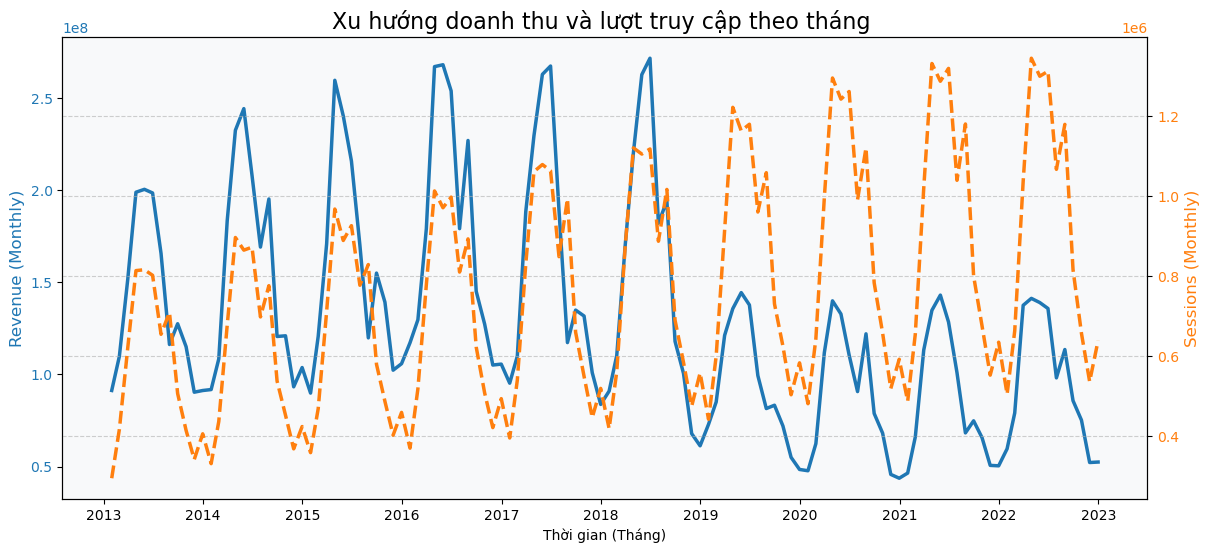

In [68]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales_filtered = df_sales[df_sales['Date'] >= '2013-01-01'].copy()
df_sales_filtered = df_sales_filtered.set_index('Date')
df_traffic_indexed = df_web_traffic.groupby('date').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
})

df_combined = df_sales_filtered.join(df_traffic_indexed, how='inner') # Dùng inner để đảm bảo ngày nào cũng có dữ liệu cả 2 bảng

df_monthly = df_combined.resample('M').agg({'Revenue': 'sum', 'sessions': 'sum'})


fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1: Revenue
color = 'tab:blue'
ax1.set_xlabel('Thời gian (Tháng)')
ax1.set_ylabel('Revenue (Monthly)', color=color, fontsize=12)
ax1.plot(df_monthly.index, df_monthly['Revenue'], color=color, linewidth=2.5, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)

# Trục 2: Sessions
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Sessions (Monthly)', color=color, fontsize=12)
ax2.plot(df_monthly.index, df_monthly['sessions'], color=color, linestyle='--', linewidth=2.5, label='Sessions')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Xu hướng doanh thu và lượt truy cập theo tháng ', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
# Tính trung bình các chỉ số theo nguồn traffic
traffic_analysis = df_web_traffic.groupby('traffic_source').agg({
    'unique_visitors': 'sum',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
})
print(traffic_analysis)

                unique_visitors  bounce_rate  avg_session_duration_sec
traffic_source                                                        
direct                  4986650     0.004511                207.678195
email_campaign          9700462     0.004458                213.220594
organic_search         20625107     0.004504                211.153945
paid_search            14922386     0.004478                209.362117
referral                7220019     0.004499                207.558667
social_media           12048065     0.004476                210.290190


Bounce rate (tỷ lệ thoát) là phần trăm số lượt truy cập website mà người dùng chỉ xem một trang duy nhất rồi rời đi mà không tương tác thêm (nhấp vào liên kết, điền form,...). 
-> thấp trang thu hút người xem

#### Lượng khách truy cập và Tỷ lệ chuyển đổi theo năm

In [70]:
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_web_traffic['year'] = df_web_traffic['date'].dt.year

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['year'] = df_orders['order_date'].dt.year

# Orders theo năm
yearly_orders = df_orders.groupby('year')['order_id'].nunique()

# Visitors theo năm
yearly_visitors = df_web_traffic.groupby('year')['unique_visitors'].sum()

# Combine
df_cr_year = pd.DataFrame({
    'Orders': yearly_orders,
    'Visitors': yearly_visitors
}).fillna(0)

# CR
df_cr_year['Conversion_Rate'] = (df_cr_year['Orders'] / df_cr_year['Visitors']) * 100




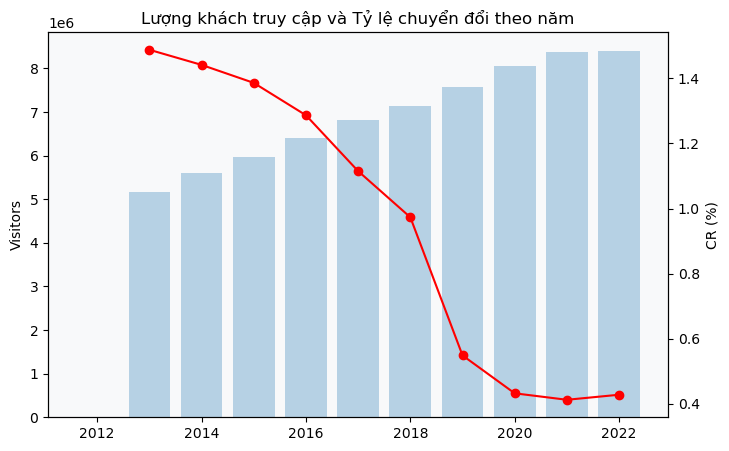

In [71]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar: Visitors
ax1.bar(df_cr_year.index, df_cr_year['Visitors'], alpha=0.3)
ax1.set_ylabel('Visitors')

# Line: CR
ax2 = ax1.twinx()
ax2.plot(df_cr_year.index, df_cr_year['Conversion_Rate'], color='red', marker='o')
ax2.set_ylabel('CR (%)')

plt.title('Lượng khách truy cập và Tỷ lệ chuyển đổi theo năm')
plt.show()

Tại sao: Ngay khi thấy doanh thu giảm, câu hỏi đặt ra là : "Tại sao?". Biểu đồ này chứng minh rằng vấn đề nằm ở hiệu suất chuyển đổi (CR lao dốc).
Thông điệp: "Chúng ta không mất khách, chúng ta đánh mất khả năng thuyết phục họ mua hàng." Câu hỏi đặt ra là tại sao họ vẫn vô web để xem hàng nhưng không chuyển đổi thành lượt mua? (có thể do các kênh bán, chất lượng sản phẩm,... )

#### Giả thuyết đặt ra:

- Giả thuyết A (Traffic Quality): Lưu lượng truy cập đang bị"pha loãng" bởi các kênh tiếp thị kém chất lượng (kênh rác), gây lãng phí ngân sách mà không tạo ra doanh thu thực tế.

- Giả thuyết B (Customer Trust Decay):Các vấn đề về hàng lỗi (`defective items`) đã tích tụ theo thời gian, tạo ra "rào cản tâm lý" (invisible barrier) khiến khách hàng tiềm năng ngần ngại trước khi quyết định thanh toán.


1. Kiểm chứng Giả thuyết A (Traffic Quality)

    -  Kênh nào kéo CR xuống?

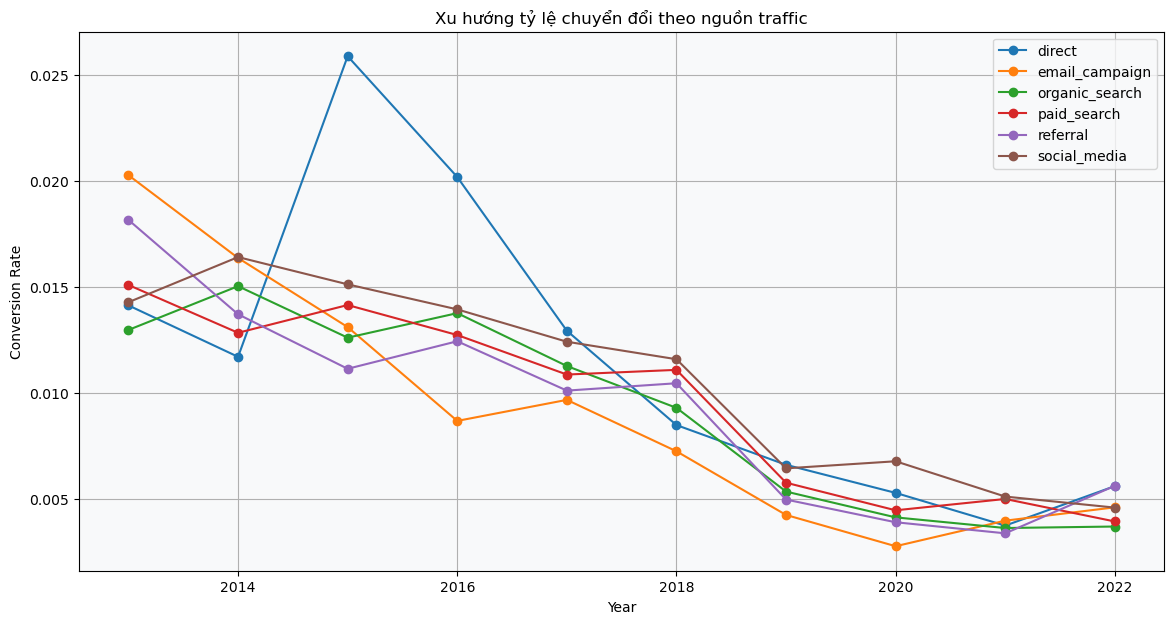

In [72]:
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_web_traffic['year'] = df_web_traffic['date'].dt.year
df_orders['year'] = df_orders['order_date'].dt.year
df_web_traffic['traffic_source'] = df_web_traffic['traffic_source'].str.lower().str.strip()
df_orders['order_source'] = df_orders['order_source'].str.lower().str.strip()


# =========================
# 2. AGGREGATE DATA
# =========================

# Traffic side
traffic_by_source = df_web_traffic.groupby(
    ['year', 'traffic_source']
)['unique_visitors'].sum().reset_index()

# Orders side
orders_by_source = df_orders.groupby(
    ['year', 'order_source']
)['order_id'].nunique().reset_index()


# =========================
# 3. MERGE DATA
# =========================

df_channel = traffic_by_source.merge(
    orders_by_source,
    left_on=['year', 'traffic_source'],
    right_on=['year', 'order_source'],
    how='left'
).fillna(0)

# Optional: drop duplicate column
df_channel.drop(columns=['order_source'], inplace=True)


# =========================
# 4. CONVERSION RATE
# =========================

df_channel['CR'] = df_channel['order_id'] / df_channel['unique_visitors']


# =========================
# 5. PIVOT FOR VISUALIZATION
# =========================

df_pivot = df_channel.pivot(
    index='traffic_source',
    columns='year',
    values='CR'
)


# =========================
# 6. PLOT (MULTI-LINE)
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for channel in df_pivot.index:
    plt.plot(
        df_pivot.columns,
        df_pivot.loc[channel],
        marker='o',
        label=channel
    )
plt.title("Xu hướng tỷ lệ chuyển đổi theo nguồn traffic")
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Conversion Rate")
plt.legend()
plt.grid(True)

plt.show()

Ta thấy rằng: All channels đều giảm có thể niềm tin thương hiệu (Brand Trust) đã bị xói mòn do tích tụ trải nghiệm tiêu cực (từ hàng lỗi) trong thời gian dài.Nếu vấn đề nằm ở marketing, CR sẽ giảm không đồng đều giữa các kênh. Tuy nhiên, dữ liệu cho thấy CR giảm trên tất cả các kênh.
	
>**Bác bỏ giả thuyết này**


2. Giả thuyết B: Suy giảm niềm tin khách hàng

In [73]:
# Tỷ lệ phần trăm các lý do trả hàng
# SQL: SELECT t1.*, t2.segment, t2.size FROM returns t1 JOIN products t2 ON t1.product_id = t2.product_id
# Pandas:
df_merged = df_returns.merge(
    df_products[['product_id', 'segment', 'size']], # Chỉ lấy những cột cần thiết từ bảng phải
    on='product_id', 
    how='left'
)
# Tổng số đơn trả hàng
total_returns = df_merged['return_id'].count()
# Đếm số lượng theo từng lý do
reason_counts = df_merged['return_reason'].value_counts()
# Tính tỷ lệ %
reason_percentage = (reason_counts / total_returns * 100)
print(reason_percentage)

return_reason
wrong_size          34.970831
defective           20.080623
not_as_described    17.614362
changed_mind        17.353965
late_delivery        9.980220
Name: count, dtype: float64


Hơn **50%** các đơn trả hàng không đến từ lỗi sản phẩm hay vận hành có thể đến từ việc khách hàng không có đủ thông tin chính xác để đưa ra quyết định đúng ngay từ đầu 


In [74]:
# Kiểm tra tỷ lệ lỗi 'wrong_size' trên toàn bộ các danh mục
# Tính tổng số đơn trả lại
total_returns = df_merged.groupby('segment')['return_id'].count()

# Tính số đơn trả lại do 'wrong_size'
wrong_size_returns = df_merged[df_merged['return_reason'] == 'wrong_size'].groupby('segment')['return_id'].count()

# Tỷ lệ phần trăm
percentage_wrong_size = (wrong_size_returns / total_returns * 100).fillna(0)

print("Tỷ lệ trả hàng do Wrong Size trên từng Segment:")
print(percentage_wrong_size)

Tỷ lệ trả hàng do Wrong Size trên từng Segment:
segment
Activewear     35.085976
All-weather    35.294118
Balanced       34.259754
Everyday       35.216405
Performance    35.391400
Premium        34.320557
Standard       34.109817
Trendy         34.477893
Name: return_id, dtype: float64


Tỷ lệ ~34–35% ở tất cả các segment
Không có sự khác biệt đáng kể giữa các nhóm sản phẩm


In [75]:
# Tỷ lệ lỗi `not_as_described` 

#  Merge cho bảng order_items (để lấy dữ liệu doanh thu/số lượng bán)
df_order_items_merged = df_order_items.merge(
    df_products[['product_id', 'segment', 'size']], 
    on='product_id', 
    how='left'
)
df_returns_merged = df_merged  # Bảng đã merge giữa returns và products để có segment và size

total_sales_by_seg = df_order_items_merged.groupby('segment')['quantity'].sum()
content_errors = df_returns_merged[df_returns_merged['return_reason'] == 'not_as_described'] \
                 .groupby('segment')['return_quantity'].sum()

content_failure_rate = (content_errors / total_sales_by_seg).fillna(0)
content_failure_rate

segment
Activewear     0.005990
All-weather    0.005438
Balanced       0.005917
Everyday       0.006000
Performance    0.006280
Premium        0.006245
Standard       0.005983
Trendy         0.006173
dtype: float64

Tỷ lệ lỗi `not_as_described` ổn định ở mức ~0.6% trên toàn bộ 8 phân khúc.


> Đây là một lỗi hệ thống, không phải lỗi cục bộ.

Câu hỏi đặt ra vậy vấn đề nằm ở đây mà khiến tất cả sản phẩm đều có tỷ lệ trả hàng xấp xỉ nhauu? Điều gì trong trải nghiệm mua hàng đang ảnh hưởng đồng loạt đến tất cả khách hàng, bất kể phân khúc sản phẩm?

Để kiểm chứng giả thuyết về sự suy giảm niềm tin khách hàng, nhóm tiến hành phân tích dữ liệu đánh giá (ratings) và nội dung phản hồi (review titles).


**Phân bố rating**

In [76]:
df_reviews['sentiment'] = df_reviews['rating'].apply(
    lambda x: 'negative' if x <= 2 else ('neutral' if x == 3 else 'positive')
)

df_reviews['sentiment'].value_counts(normalize=True)

sentiment
positive    0.719219
neutral     0.149853
negative    0.130928
Name: proportion, dtype: float64

In [77]:
df_reviews['rating'].value_counts(normalize=True).sort_index()

rating
1    0.050832
2    0.080096
3    0.149853
4    0.320666
5    0.398552
Name: proportion, dtype: float64

Khoảng 72% đánh giá nằm ở mức 4–5 sao

Khoảng 28% còn lại từ 3 sao trở xuống

Ở mức tổng quan, hệ thống đánh giá dường như vẫn tích cực. Tuy nhiên, phân tích sâu hơn về nội dung phản hồi cho thấy một bức tranh khác biệt.


In [78]:
low_reviews = df_reviews[df_reviews['rating'] <= 2]

result = low_reviews['review_title'].value_counts().reset_index()
result.columns = ['review_title', 'count']

result

,review_title,count
0,Some issues,3037
1,Would not reorder,3034
2,Below expectations,3024
3,Would not recommend,1460
4,Poor quality,1443
5,Very disappointed,1442
6,Not as described,1427


> Phản hồi tiêu cực của khách hàng bị “tập trung hóa” vào một số nhóm cố định

1. Vấn đề chất lượng sản phẩm

    - Poor quality
    - Very disappointed

> nghĩa là hàng không đạt kỳ vọng về chất lượng

2. Sai lệch kỳ vọng (expectation mismatch)

    - Below expectations
    - Not as described

> khách thấy sản phẩm không giống mô tả / hình ảnh

3. Hối tiếc sau mua hàng

    - Would not reorder
    - Would not recommend
    - Some issues

> khách không muốn quay lại hoặc không hài lòng tổng thể

Mặc dù rating trung bình vẫn ở mức cao, nội dung phản hồi lại cho thấy sự bất mãn tiềm ẩn trong trải nghiệm khách hàng.

Có thể khách hàng không phản ứng mạnh bằng rating thấp nhưng lại âm thầm rời bỏ thương hiệu hay chăng?


**Tính AOV**

AOV (Average Order Value) là chỉ số Giá trị đơn hàng trung bình, đo lường số tiền trung bình khách hàng chi tiêu cho mỗi lần mua hàng

In [79]:
yr = df_sales.groupby(df_sales["Date"].dt.year)["Revenue"].sum().reset_index()
yr.columns = ["year", "revenue"]
orders_year = df_orders.groupby(df_orders["order_date"].dt.year)["order_id"].nunique().reset_index()
orders_year.columns = ["year", "orders"]
yr = yr.merge(orders_year, on="year", how="left")
yr["aov"] = yr["revenue"] / yr["orders"]

Text(0.5, 1.0, 'Doanh thu và số đơn hàng theo năm')

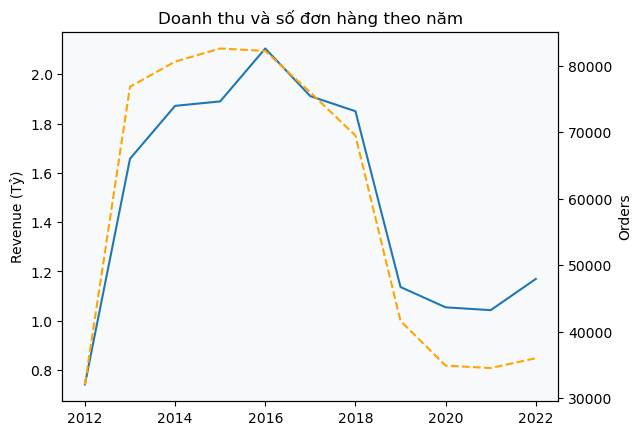

In [80]:
fig, ax1 = plt.subplots()

ax1.plot(yr["year"], yr["revenue"]/1e9, label="Revenue")
ax1.set_ylabel("Revenue (Tỷ)")

ax2 = ax1.twinx()
ax2.plot(yr["year"], yr["orders"], linestyle="--", label="Orders", color="orange")
ax2.set_ylabel("Orders")

plt.title("Doanh thu và số đơn hàng theo năm")

Text(0.5, 1.0, 'Doanh thu và AOV theo thời gian')

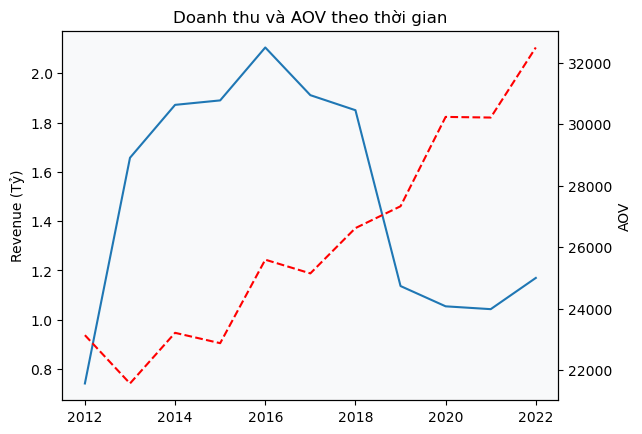

In [81]:
fig, ax1 = plt.subplots()

# Revenue
ax1.plot(yr["year"], yr["revenue"]/1e9)
ax1.set_ylabel("Revenue (Tỷ)")

# AOV (trục phụ)
ax2 = ax1.twinx()
ax2.plot(yr["year"], yr["aov"], linestyle="--",  color="red")
ax2.set_ylabel("AOV")

plt.title("Doanh thu và AOV theo thời gian")

Doanh thu có xu hướng giảm cùng với số lượng đơn hàng, đặc biệt sau năm 2016. Điều này cho thấy sự sụt giảm doanh thu chủ yếu đến từ việc giảm số lượng đơn hàng, thay vì do giá trị mỗi đơn (AOV). Mặc dù AOV có xu hướng tăng, nhưng không đủ bù đắp cho sự giảm mạnh về số lượng đơn.

New vs Returning customers

In [82]:
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders["year"] = df_orders["order_date"].dt.year
df_orders = df_orders.sort_values("order_date")
df_orders["first_purchase"] = df_orders.groupby("customer_id")["order_date"].transform("min")
df_orders["is_new"] = df_orders["order_date"] == df_orders["first_purchase"]

new_customers = (
    df_orders[df_orders["is_new"]]
    .groupby("year")["customer_id"]
    .nunique()
)

returning_customers = (
    df_orders[~df_orders["is_new"]]
    .groupby("year")["customer_id"]
    .nunique()
)

new_customers, returning_customers = new_customers.align(returning_customers, fill_value=0)

In [83]:
total_customers = df_orders.groupby("year")["customer_id"].nunique()

new_ratio = new_customers / total_customers
returning_ratio = returning_customers / total_customers

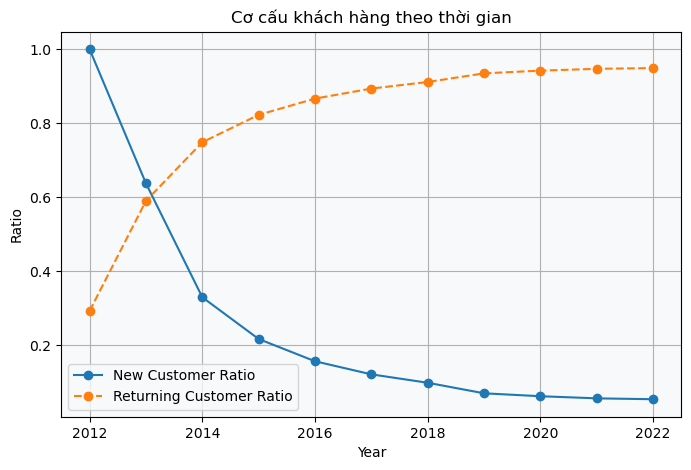

In [84]:
plt.figure(figsize=(8,5))

plt.plot(new_ratio.index, new_ratio.values, marker="o", label="New Customer Ratio")
plt.plot(returning_ratio.index, returning_ratio.values, marker="o", linestyle="--", label="Returning Customer Ratio")

plt.title("Cơ cấu khách hàng theo thời gian")
plt.xlabel("Year")
plt.ylabel("Ratio")

plt.legend()
plt.grid(True)

plt.show()

In [85]:
returning_ratio

year
2012    0.292097
2013    0.589833
2014    0.748440
2015    0.822481
2016    0.866465
2017    0.893647
2018    0.911423
2019    0.934791
2020    0.942100
2021    0.947006
2022    0.949020
Name: customer_id, dtype: float64

- Tỷ lệ khách hàng quay lại tăng mạnh trong giai đoạn đầu (2012–2015), sau đó tăng chậm và dần ổn định quanh mức ~94–95% từ năm 2019 trở đi. Điều này cho thấy doanh nghiệp đã đạt trạng thái bão hòa về khả năng giữ chân khách hàng. Tăng trưởng trong tương lai nhiều khả năng không còn đến từ cải thiện retention mà sẽ phụ thuộc vào mở rộng tệp khách hàng mới hoặc tăng giá trị trên mỗi khách hàng hiện tại.

- Tỷ lệ khách hàng quay lại tăng không phải do cải thiện sự trung thành, mà do sự sụt giảm mạnh của khách hàng mới. Điều này cho thấy hệ thống đang gặp vấn đề trong việc thu hút khách hàng mới, dẫn đến việc phụ thuộc vào một tập khách hàng hiện hữu ngày càng nhỏ.

- Mặc dù tỷ lệ khách hàng quay lại tăng theo thời gian, điều này không phản ánh sự cải thiện về mức độ trung thành. Ngược lại, tỷ lệ khách hàng mới giảm mạnh cho thấy nền tảng đang gặp khó khăn trong việc thu hút người dùng mới. Kết hợp với các phản hồi tiêu cực từ khách hàng, có thể thấy dấu hiệu suy giảm niềm tin, khiến khách hàng không quay lại và hạn chế việc lan tỏa tích cực. Điều này dẫn đến việc số lượng đơn hàng giảm, trong khi AOV tăng do chỉ còn lại nhóm khách hàng có mức chi tiêu cao hơn.